In [1]:
import pathlib

import folium
import mcr_py
import mcr_py.gtfs
import mcr_py.utils.footpaths
import mcr_py.utils.geometa
import polars as pl
import shapely
from mcr_py.utils.geometa import GeoMeta

In [2]:
df = pl.read_parquet("../data/sharing_locations_raw/tier_availability_cologne.parquet")
df = pl.read_parquet("../data/20250926/cache/koeln_pois_nodes.parquet")

In [3]:
df

osm_id,lat,long,nearest_osm_node,dist_to_nearest,poi_type
u64,f64,f64,u64,f64,str
359832,50.9052,6.9639347,5037905362,14.73823,"""Sustenance"""
28123308,50.940458,6.9740513,801093980,7.564851,"""Grocery"""
30876796,51.09301,6.8889512,11847227074,12.453673,"""Grocery"""
34969200,51.095009,6.8866234,12563804993,24.745516,"""Education"""
53979527,50.943096,6.8987719,1726927775,32.194395,"""Shops"""
…,…,…,…,…,…
13115441016,50.950599,6.873587,13115441034,6.650259,"""Parks"""
13115441017,50.950594,6.8737127,2590869360,6.838907,"""Parks"""
13115441018,50.950621,6.8736821,12634818389,5.791763,"""Parks"""


In [4]:
bounding_box = [
    (6.912789559592028, 50.95082420629814),
    (6.90965014627875, 50.94788724437913),
    (6.912218504273028, 50.94473937866948),
    (6.914029522915655, 50.944306400295005),
    (6.916940125566271, 50.946735585299706),
    (6.919886618643858, 50.94555227853371),
    (6.9237266503584465, 50.94991721673625),
    (6.926592441418052, 50.951705692912014),
    (6.925031390065072, 50.95226859486215),
    (6.923008239592917, 50.95206669530157),
    (6.923878775814018, 50.952914472192305),
    (6.921391875103581, 50.95386602541586),
    (6.919528164440663, 50.951875256766186),
    (6.912789559592028, 50.95082420629814),
]

geometa = mcr_py.utils.geometa.GeoMeta.create(
    shapely.Polygon(bounding_box), "EPSG:4326", "EPSG:4839", buffer=0
)
# geometa.save("../osmtools/data/geometa.json")
# mcr_py.command.gtfs.gtfs.crop_command(
#     "../data/20250512/gtfs_raw/germany.zip",
#     "../osmtools/data/gtfs_crop.zip",
#     "01.01.1970-00:00:00",
#     "01.01.2050-00:00:00",
#     geometa_path="../osmtools/data/geometa.json",
# )
# mcr_py.command.gtfs.gtfs.clean_gtfs(
#     "../osmtools/data/gtfs_crop.zip", "../osmtools/data/gtfs"
# )

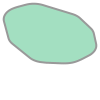

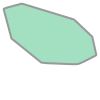

In [5]:
base_directory = pathlib.Path("../data/20250926")
city_name = "cologne"
geometa = GeoMeta.load(base_directory / f"cache/{city_name}_geometa.json")
display(shapely.from_wkt(geometa.boundary_wkt).convex_hull)
display(shapely.from_wkt(geometa.unbuffered_boundary_wkt).convex_hull)

In [6]:
# (df_nodes, df_edges, _) = mcr_py.load_osm_walking(
#     "koeln", bounding_box, "../osmtools/data/", "../osmtools/data", False
# )
# display(df_nodes.head())
# (df_c_nodes, df_c_edges, _) = mcr_py.load_osm_cycling(
#     "koeln", bounding_box, True, "../osmtools/data/", "../osmtools/data", False
# )
# (df_d_nodes, df_d_edges, _) = mcr_py.load_osm_driving(
#     "koeln", bounding_box, "../osmtools/data/", "../osmtools/data", False
# )
# (df_pois) = mcr_py.load_osm_pois(
#     "koeln",
#     bounding_box,
#     "../osmtools/data/",
#     "../osmtools/data",
#     False,
#     nodes_to_match_df=df_nodes,  # "../osmtools/data/koeln_walking_nodes.parquet",
# )

In [7]:
import mcr_py.osm.graph

df_nodes = pl.read_parquet("../data/20250808/cache/koeln_walking_nodes.parquet")
df_mapping = pl.read_parquet("../data/20250808/cache/koeln_walking_h3mapping.parquet")
df_c_nodes = pl.read_parquet("..//data/20250808/cache/koeln_cycling_nodes.parquet")
df_d_nodes = pl.read_parquet("../data/20250808/cache/koeln_driving_nodes.parquet")
df_edges = pl.read_parquet("../data/20250808/cache/koeln_walking_edges.parquet")
df_c_edges = pl.read_parquet("../data/20250808/cache/koeln_cycling_edges.parquet")
df_d_edges = pl.read_parquet("../data/20250808/cache/koeln_driving_edges.parquet")
df_pois = pl.read_parquet("../data/20250808/cache/koeln_pois_nodes.parquet")
(df_nodes, df_edges, graph) = mcr_py.osm.graph.create_rx_graph(df_nodes, df_edges)

In [8]:
# df_nodes = pl.read_parquet("../osmtools/test/bruegge_walking_nodes.parquet")
# df_edges = pl.read_parquet("../osmtools/test/bruegge_walking_edges.parquet")
# df_mapping = pl.read_parquet("../osmtools/test/bruegge_walking_h3mapping.parquet")
# df_c_nodes = pl.read_parquet("../osmtools/test/bruegge_cycling_nodes.parquet")
# df_c_edges = pl.read_parquet("../osmtools/test/bruegge_cycling_edges.parquet")
# df_c_mapping = pl.read_parquet("../osmtools/test/bruegge_cycling_h3mapping.parquet")
# df_d_nodes = pl.read_parquet("../osmtools/test/bruegge_driving_nodes.parquet")
# df_d_edges = pl.read_parquet("../osmtools/test/bruegge_driving_edges.parquet")
# df_d_mapping = pl.read_parquet("../osmtools/test/bruegge_driving_h3mapping.parquet")

# df_pois = pl.read_parquet("../osmtools/test/bruegge_pois_nodes.parquet")

# (df_nodes, df_edges, graph) = mcr_py.osm.graph.create_rx_graph(df_nodes, df_edges)

In [9]:
import polars_h3 as plh3
import polars_st as st

test_pl_query = (
    df_nodes.lazy()
    .with_columns(
        plh3.latlng_to_cell(
            pl.col("lat"),
            pl.col("long"),
            8,
            return_dtype=pl.String,
        ).alias("h3_cell"),
        st.point(pl.concat_arr("long", "lat")).st.set_srid(4326).alias("point_lnglat"),
    )
    .with_columns(
        st.point(
            pl.concat_arr(
                plh3.cell_to_lng(pl.col("h3_cell")),
                plh3.cell_to_lat(pl.col("h3_cell")),
            )
        )
        .st.set_srid(4326)
        .alias("h3_cell_lnglat")
    )
    .with_columns(
        st.to_srid("point_lnglat", srid=4839)
        .st.distance(st.to_srid("h3_cell_lnglat", srid=4839))
        .alias("distance_to_cell"),
        plh3.cell_to_lat(pl.col("h3_cell")).alias("h3_cell_lat"),
        plh3.cell_to_lng(pl.col("h3_cell")).alias("h3_cell_long"),
    )
    .group_by("h3_cell")
    .agg(pl.all().sort_by("distance_to_cell").first())
    .select(
        "osm_id",
        "h3_cell",
        "h3_cell_lat",
        "h3_cell_long",
    )
    .collect()
)

In [ ]:
start_nodes = [268504342, 218556113, 5822410905, 259636692, 32248903, 585611, 359457]
location_names = [
    "Blumenberg",
    "TTC_RotGold",
    "Melatenguertel",
    "inovex",
    "KlaraStr",
    "RiehlerStr",
    "is3",
]
comb = dict(zip(start_nodes, location_names, strict=True))
df_nodes.filter(pl.col("osm_id").is_in(start_nodes)).select(pl.col("osm_id")).with_columns(
    hex_id=pl.col("osm_id").replace_strict(comb, return_dtype=pl.String)
)

osm_id,hex_id
u64,str
359457,"""is3"""
585611,"""RiehlerStr"""
32248903,"""KlaraStr"""
218556113,"""TTC_RotGold"""
259636692,"""inovex"""
268504342,"""Blumenberg"""
5822410905,"""Melatenguertel"""


In [ ]:
test_pl_query

osm_id,h3_cell,h3_cell_lat,h3_cell_long
u64,str,f64,f64
271022560,"""881fa1915bfffff""",51.104533,6.964328
615029192,"""881fa18049fffff""",51.037299,7.116137
10703787380,"""881fa19335fffff""",51.107666,6.927396
331936397,"""881fa1c71bfffff""",50.763803,6.901872
1615579526,"""881fa1880dfffff""",50.881867,7.029988
…,…,…,…
243973895,"""881fa19827fffff""",50.961275,6.895884
7968246846,"""881fa18193fffff""",50.968053,7.209839
850891029,"""881fa1d423fffff""",50.832992,6.80831


In [ ]:
st.polygon(pl.lit([geometa.get_convex_hull_coord_list(use_buffer=False)]))

<Expr ['[[[7.0625234, 50.83044], [6.95…'] at 0x702B0AE21A20>

In [ ]:
filtered_cells = test_pl_query.filter(
    st.point(pl.concat_arr(pl.col("h3_cell_long"), pl.col("h3_cell_lat")))
    .st.set_srid(4326)
    .st.within(
        st.polygon(pl.lit([geometa.get_convex_hull_coord_list(use_buffer=False)])).st.set_srid(
            4326
        )
    )
)
hex_map = plh3.graphing.plot_hex_outlines(filtered_cells, "h3_cell")

p1 = folium.Polygon(
    locations=[[y, x] for [x, y] in geometa.get_convex_hull_coord_list(use_buffer=False)],
    color="green",
)
p1.add_to(hex_map)
p2 = folium.Polygon(
    locations=[[y, x] for [x, y] in geometa.get_convex_hull_coord_list(use_buffer=True)],
    color="blue",
)
p2.add_to(hex_map)


hex_map

In [ ]:
df_pois.join(
    df_nodes.select("osm_id", "rx_node_id"),
    left_on="nearest_osm_node",
    right_on="osm_id",
).with_columns(pl.col("rx_node_id").alias("nearest_osm_node"))

osm_id,lat,long,nearest_osm_node,dist_to_nearest,poi_type,rx_node_id
u64,f64,f64,u64,f64,str,u64
5123458821,51.208008,3.2219794,0,5.401037,"""Shops""",0
1184795043,51.207798,3.2232925,7,9.631137,"""Shops""",7
1184858513,51.207706,3.2231393,7,13.38017,"""Shops""",7
1184858578,51.207747,3.2231945,7,10.151185,"""Grocery""",7
4171442147,51.207645,3.2234651,7,12.143663,"""Shops""",7
…,…,…,…,…,…,…
5627621699,51.207414,3.2282243,1753,11.113663,"""Sustenance""",1753
4294775440,51.206492,3.2335368,1773,10.745448,"""Grocery""",1773
12291403675,51.205936,3.2329912,1782,4.741936,"""Sustenance""",1782


In [ ]:
from mcr_py.mcr.data import (
    AVG_WALKING_SPEED,
    TRAVEL_TIME_COLUMN,
    add_travel_time,
    add_weights,
)

add_weights(add_travel_time(df_edges, AVG_WALKING_SPEED), [TRAVEL_TIME_COLUMN], False).head()

source_osm,dest_osm,length,source_rx_node_id,dest_rx_node_id,travel_time,weights
u64,u64,f64,u64,u64,f64,str
17421084,12075818966,4.456771,0,1317,3.183408,"""(3,0)"""
17421084,12075818967,4.831027,0,1318,3.450734,"""(3,0)"""
17421085,315787871,21.122802,1,150,15.087715,"""(15,0)"""
17421085,12075818966,22.788618,1,1317,16.277584,"""(16,0)"""
17421090,4972686949,0.365403,2,681,0.261002,"""(0,0)"""


In [ ]:
(nodes_after, edges_after, graph_after) = mcr_py.osm.graph.crop_graph_to_largest_component(
    graph, df_nodes, df_edges
)
paths = mcr_py.osm.graph.shortest_paths(graph_after)
df_pois_added = mcr_py.add_nearest_node_to_df(df_pois, nodes_after, 4839)

In [ ]:
def get_coordinates(df_edges, df_nodes):
    return df_edges.join(
        df_nodes.select(
            pl.col("osm_id"),
            pl.col("lat").alias("from_lat"),
            pl.col("long").alias("from_lon"),
        ),
        left_on="source_osm",
        right_on="osm_id",
    ).join(
        df_nodes.select(
            pl.col("osm_id"),
            pl.col("lat").alias("dest_lat"),
            pl.col("long").alias("dest_lon"),
        ),
        left_on="dest_osm",
        right_on="osm_id",
    )

In [ ]:
df_pois = df_pois.join(
    df_nodes.select(
        pl.col("osm_id"),
        pl.col("lat").alias("nearest_lat"),
        pl.col("long").alias("nearest_lon"),
    ),
    left_on="nearest_osm_node",
    right_on="osm_id",
)

df_edges = get_coordinates(df_edges, df_nodes)
df_c_edges = get_coordinates(df_c_edges, df_c_nodes)
df_d_edges = get_coordinates(df_d_edges, df_d_nodes)
edges_after = get_coordinates(edges_after, nodes_after)
df_mapping = df_mapping.join(
    df_nodes.select(pl.col("osm_id"), pl.col("lat"), pl.col("long")),
    left_on="osm_node_id",
    right_on="osm_id",
)
df_c_mapping = df_c_mapping.join(
    df_c_nodes.select(pl.col("osm_id"), pl.col("lat"), pl.col("long")),
    left_on="osm_node_id",
    right_on="osm_id",
)
df_d_mapping = df_d_mapping.join(
    df_d_nodes.select(pl.col("osm_id"), pl.col("lat"), pl.col("long")),
    left_on="osm_node_id",
    right_on="osm_id",
)

In [ ]:
df_edges = df_edges.with_columns(
    pl.concat_list(pl.col("source_osm").cast(pl.String), pl.col("dest_osm").cast(pl.String))
    .list.sort()
    .list.join("")
    .is_duplicated()
    .alias("duplicated")
)
df_c_edges = df_c_edges.with_columns(
    pl.concat_list(pl.col("source_osm").cast(pl.String), pl.col("dest_osm").cast(pl.String))
    .list.sort()
    .list.join("")
    .is_duplicated()
    .alias("duplicated")
)
df_d_edges = df_d_edges.with_columns(
    pl.concat_list(pl.col("source_osm").cast(pl.String), pl.col("dest_osm").cast(pl.String))
    .list.sort()
    .list.join("")
    .is_duplicated()
    .alias("duplicated")
)

In [40]:
import polars_h3 as plh3

hex_map = plh3.graphing.plot_hex_outlines(df_mapping, "h3_cell_id")
geometa.add_to_folium_map(hex_map)
hex_map

In [ ]:
m = folium.Map(location=[51.20391, 3.22183], zoom_start=15)
fg_walking = folium.FeatureGroup("Walking")
for edge in df_edges.iter_rows(named=True):
    folium.PolyLine(
        locations=[
            [edge["from_lat"], edge["from_lon"]],
            [edge["dest_lat"], edge["dest_lon"]],
        ],
        color="blue" if not edge["duplicated"] else "lightblue",
        popup=f"{edge['source_osm']}",
        weight=2,
        opacity=1,
    ).add_to(fg_walking)
fg_walking.add_to(m)

fg_cycling = folium.FeatureGroup("Cycling")
for edge in df_c_edges.iter_rows(named=True):
    folium.PolyLine(
        locations=[
            [edge["from_lat"], edge["from_lon"]],
            [edge["dest_lat"], edge["dest_lon"]],
        ],
        color="green" if not edge["duplicated"] else "lightgreen",
        weight=2,
        opacity=1,
    ).add_to(fg_cycling)
fg_cycling.add_to(m)
fg_driving = folium.FeatureGroup("Driving")
for edge in df_d_edges.iter_rows(named=True):
    folium.PolyLine(
        locations=[
            [edge["from_lat"], edge["from_lon"]],
            [edge["dest_lat"], edge["dest_lon"]],
        ],
        color="red" if not edge["duplicated"] else "lightcoral",
        weight=2,
        opacity=1,
    ).add_to(fg_driving)
fg_driving.add_to(m)
fg_cropped = folium.FeatureGroup("Cropped")
for edge in edges_after.iter_rows(named=True):
    folium.PolyLine(
        locations=[
            [edge["from_lat"], edge["from_lon"]],
            [edge["dest_lat"], edge["dest_lon"]],
        ],
        color="brown",
        weight=2,
        opacity=1,
    ).add_to(fg_cropped)
fg_cropped.add_to(m)

for node in df_mapping.iter_rows(named=True):
    folium.Marker(location=[node["lat"], node["long"]], popup=node["h3_cell_id"]).add_to(
        fg_cropped
    )
for node in df_c_mapping.iter_rows(named=True):
    folium.Marker(location=[node["lat"], node["long"]], popup=node["h3_cell_id"]).add_to(
        fg_cropped
    )
for node in df_d_mapping.iter_rows(named=True):
    folium.Marker(location=[node["lat"], node["long"]], popup=node["h3_cell_id"]).add_to(
        fg_cropped
    )


folium.LayerControl().add_to(m)
m

In [ ]:
m = folium.Map(location=[50.949, 6.916], zoom_start=15)
for node in df.iter_rows(named=True):
    folium.Circle(
        location=[node["lat"], node["long"]],
        popup=f"Node {node['type']}",
        radius=1,
        color="green",
    ).add_to(m)

    # folium.Circle(
    #     location=[node["nearest_lat"], node["nearest_lon"]],
    #     popup=f"Node {node['nearest_osm_node']}",
    #     radius=1,
    # ).add_to(m)

    # folium.PolyLine(
    #     locations=[
    #         [node["lat"], node["long"]],
    #         [node["nearest_lat"], node["nearest_lon"]],
    #     ],
    #     color="red",
    #     weight=2,
    #     opacity=1,
    # ).add_to(m)

# for node in df_nodes.iter_rows(named=True):
#     folium.Circle(
#         location=[node["lat"], node["long"]],
#         popup=f"Node {node['osm_id']}",
#         radius=1,
#     ).add_to(m)

m

In [2]:
footpaths = mcr_py.utils.footpaths.generate(
    "koeln", "../osmtools/data", "../osmtools/data/gtfs/stops.parquet", 1.4
)

{16: {'stop_name': 'Köln Ehrenfeld Körnerstr.', 'parent_station': 584990, 'stop_id': 278765, 'stop_lat': 50.94841, 'stop_lon': 6.920253, 'location_type': None, 'geometry': b'\x01\x01\x00\x00\x00\xfd.l\xcdV\xae\x1b@\x85\x99\xb6\x7feyI@', 'lat': 50.94841, 'long': 6.920253, 'nearest_node_osm_id': 31919968, 'nearest_node_distance': 97.51032358732719}, 65: {'stop_name': 'Köln Ehrenfeld Liebigstr.', 'parent_station': 108235, 'stop_id': 235011, 'stop_lat': 50.951736, 'stop_lon': 6.925193, 'location_type': None, 'geometry': b'\x01\x01\x00\x00\x00\xd8\xf35\xcbe\xb3\x1b@\x8269|\xd2yI@', 'lat': 50.951736, 'long': 6.925193, 'nearest_node_osm_id': 76598885, 'nearest_node_distance': 82.1340316135559}, 103: {'stop_name': 'Köln Ehrenfeld Venloer Str./Gürtel', 'parent_station': 416145, 'stop_id': 432314, 'stop_lat': 50.94917, 'stop_lon': 6.915545, 'location_type': None, 'geometry': b'\x01\x01\x00\x00\x00\xb6\x10\xe4\xa0\x84\xa9\x1b@\x13,\x0eg~yI@', 'lat': 50.94917, 'long': 6.915545, 'nearest_node_osm_i

In [9]:
stops = pl.read_parquet("../osmtools/data/gtfs/stops.parquet")
m = folium.Map(location=[50.949, 6.916], zoom_start=15)
for node in stops.iter_rows(named=True):
    if node["stop_id"] == 278765:
        folium.Marker(
            location=[node["stop_lat"], node["stop_lon"]],
            popup=f"Node {node['stop_id']}",
            radius=5,
            color="green",
        ).add_to(m)
    else:
        folium.Circle(
            location=[node["stop_lat"], node["stop_lon"]],
            popup=f"Node {node['stop_id']}",
            radius=5,
            color="green",
        ).add_to(m)
m